In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import mobilenet_v2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

In [2]:
train_dir = r"E:\CNN_SKIN_DATASET_TRAIN_TEST\train"
test_dir = r"E:\CNN_SKIN_DATASET_TRAIN_TEST\val"

In [3]:
IMG_SIZE = 160
BATCH_SIZE = 16

In [4]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [5]:
train_generator = train_datagen.flow_from_directory(train_dir
    ,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

Found 20262 images belonging to 8 classes.


In [6]:
# checking the classes of dataset for output
NUM_CLASSES = len(train_generator.class_indices)
NUM_CLASSES

8

In [7]:
#computing the weight
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_generator.classes)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(3.6547619047619047), 1: np.float64(0.9528781038374717), 2: np.float64(1.2066460219151978), 3: np.float64(13.260471204188482), 4: np.float64(0.2458980582524272), 5: np.float64(0.700235001382361), 6: np.float64(5.045318725099602), 7: np.float64(12.538366336633663)}


In [8]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 5069 images belonging to 8 classes.


In [9]:
# building the model 
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [43]:
# Freeze all  layers
for layer in base_model.layers[:-40]:
    layer.trainable = False
for layer in base_model.layers[-40:]:
    layer.trainable = True


In [44]:
x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dense(256, activation="relu")(x)
x = tf.keras.layers.Dropout(0.4)(x)
output = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = tf.keras.models.Model(base_model.input, output)

In [45]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)


In [46]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 160, 160, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 80, 80, 32)        │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 80, 80, 32)        │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 80, 80, 32)        │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 80, 80, 32)        │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 80, 80, 32)        │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 80, 80, 32)        │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 80, 80, 16)        │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 80, 80, 16)        │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 80, 80, 96)        │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 80, 80, 96)        │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 80, 80, 96)        │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 81, 81, 96)        │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 40, 40, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,587,976 (9.87 MB)

 Trainable params: 2,011,528 (7.67 MB)

 Non-trainable params: 576,448 (2.20 MB)

In [47]:
history = model.fit(
    train_generator,
    epochs=20,
    class_weight=class_weights
)


Epoch 1/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 2508s 2s/step - accuracy: 0.5250 - loss: 1.2409
Epoch 2/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1496s 1s/step - accuracy: 0.5837 - loss: 0.9906
Epoch 3/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1647s 1s/step - accuracy: 0.6107 - loss: 0.9065
Epoch 4/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1300s 1s/step - accuracy: 0.6248 - loss: 0.8367
Epoch 5/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1107s 874ms/step - accuracy: 0.6420 - loss: 0.7852
Epoch 6/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1127s 890ms/step - accuracy: 0.6550 - loss: 0.7628
Epoch 7/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1112s 877ms/step - accuracy: 0.6564 - loss: 0.6978
Epoch 8/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1145s 863ms/step - accuracy: 0.6773 - loss: 0.6835
Epoch 9/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1106s 872ms/step - accuracy: 0.6806 - loss: 0.6400
Epoch 10/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1091s 861ms/step - accuracy: 0.6849 - loss: 0.6288
Epoch 11/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1113s 870ms/step - accuracy: 0.6939 - 

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1112s 877ms/step - accuracy: 0.7245 - loss: 0.5274
Epoch 18/20
 104/1267 ━━━━━━━━━━━━━━━━━━━━ 16:50 869ms/step - accuracy: 0.7239 - loss: 0.4601

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1425s 1s/step - accuracy: 0.7320 - loss: 0.4856
Epoch 19/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1538s 1s/step - accuracy: 0.7463 - loss: 0.4624
Epoch 20/20
1267/1267 ━━━━━━━━━━━━━━━━━━━━ 1525s 1s/step - accuracy: 0.7483 - loss: 0.4442


In [48]:
loss, accuracy = model.evaluate(test_generator)
print("Test Accuracy:", accuracy)

317/317 ━━━━━━━━━━━━━━━━━━━━ 336s 1s/step - accuracy: 0.5974 - loss: 1.2932
Test Accuracy: 0.5973564982414246


In [49]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [50]:
prediction = model.predict(test_generator)

317/317 ━━━━━━━━━━━━━━━━━━━━ 187s 577ms/step


In [32]:
y_pred = np.argmax(prediction, axis=1)
y_true = test_generator.classes

In [33]:
class_labels = list(test_generator.class_indices.keys())

In [34]:
cm = confusion_matrix(y_true, y_pred)

In [35]:
cm

array([[  69,   26,   40,    1,    1,    8,   28,    1],
       [  44,  361,   84,    4,   20,   31,  110,   11],
       [  18,   18,  403,    3,   15,   47,   15,    6],
       [   1,    7,    7,   15,    9,    3,    4,    2],
       [   3,   54,  575,    5, 1504,  383,   18,   33],
       [  12,   16,  198,    1,  101,  537,   31,    9],
       [   1,   15,   11,    2,    1,   10,   85,    1],
       [   0,    2,    2,    0,    1,    1,    1,   44]])

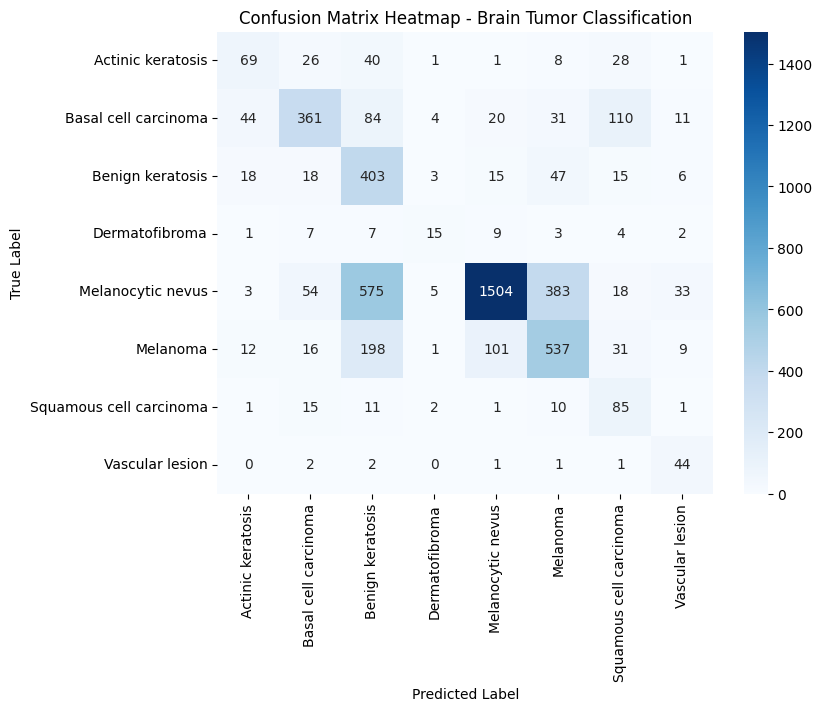

In [36]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix Heatmap - Brain Tumor Classification")
plt.show()


In [37]:
print(classification_report(
    y_true,
    y_pred,
    target_names=test_generator.class_indices.keys()
))

                         precision    recall  f1-score   support

      Actinic keratosis       0.47      0.40      0.43       174
   Basal cell carcinoma       0.72      0.54      0.62       665
       Benign keratosis       0.31      0.77      0.44       525
         Dermatofibroma       0.48      0.31      0.38        48
      Melanocytic nevus       0.91      0.58      0.71      2575
               Melanoma       0.53      0.59      0.56       905
Squamous cell carcinoma       0.29      0.67      0.41       126
        Vascular lesion       0.41      0.86      0.56        51

               accuracy                           0.60      5069
              macro avg       0.51      0.59      0.51      5069
           weighted avg       0.71      0.60      0.62      5069

